In [1]:
!pip install kagglehub[pandas-datasets]
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("abhishek14398/sms-spam-collection")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\abhishek14398\sms-spam-collection\versions\2


In [2]:
print(os.listdir(path))

['SMSSpamCollection.csv', 'SpamCollectionSMS.txt']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(f"{path}/SMSSpamCollection.csv", sep="\t", header=None, names=['label', 'text'])
df.head()

,label,text
0,"ham\tGo until jurong point, crazy.. Available ...",NaN
1,ham\tOk lar... Joking wif u oni...,NaN
2,spam\tFree entry in 2 a wkly comp to win FA Cu...,NaN
3,ham\tU dun say so early hor... U c already the...,NaN
4,"ham\tNah I don't think he goes to usf, he live...",NaN


In [5]:

with open(f"{path}/SMSSpamCollection.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()


data = []
for line in lines:
    parts = line.strip().split('\t', 1) 
    if len(parts) == 2:
        data.append(parts)

df = pd.DataFrame(data, columns=['label', 'text'])
df.head()

,label,text
0,"""ham","Go until jurong point, crazy.. Available only ..."
1,"""ham","Ok lar... Joking wif u oni..."""
2,"""spam",Free entry in 2 a wkly comp to win FA Cup fina...
3,"""ham",U dun say so early hor... U c already then say...
4,"""ham","Nah I don't think he goes to usf, he lives aro..."


In [6]:
print("Class Frequencies:")
print(df['label'].value_counts())

Class Frequencies:
label
"ham     4827
"spam     747
Name: count, dtype: int64


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19108\737619406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


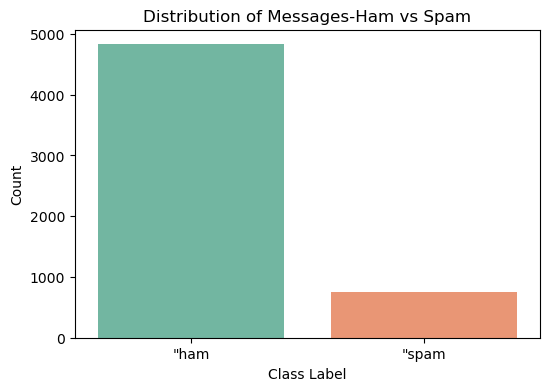

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Distribution of Messages-Ham vs Spam')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

In [8]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(raw_text):
    #lowercasing
    text = raw_text.lower()
    
    #remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    #tokenize
    tokens = text.split()
    
    #removing stopwords
    filtered_tokens = [word for word in tokens if word not in stop_words]
    
    #joining tokens back
    return " ".join(filtered_tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
df['cleaned_text'] = df['text'].apply(preprocess_text)
df[['text', 'cleaned_text']].head()

,text,cleaned_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,"Ok lar... Joking wif u oni...""",ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [10]:

df['label_clean'] = df['label'].astype(str).str.extract(r'(ham|spam)', expand=False)

df['label_encoded'] = df['label_clean'].map({'ham': 0, 'spam': 1})

df['cleaned_text'] = df['text'].astype(str).apply(preprocess_text)
print("Rows before dropna:", len(df))
print("Label value counts:\n", df['label_clean'].value_counts())
print("NaN counts in label_encoded:", df['label_encoded'].isna().sum())

df = df.dropna(subset=['label_encoded', 'cleaned_text'])
df = df[df['cleaned_text'].str.len() > 0]
df['label_encoded'] = df['label_encoded'].astype(int)

print("\nSuccess! Rows after cleaning (n_samples):", len(df))

Rows before dropna: 5574
Label value counts:
 label_clean
ham     4827
spam     747
Name: count, dtype: int64
NaN counts in label_encoded: 0

Success! Rows after cleaning (n_samples): 5568


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], 
    df['label_encoded'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label_encoded']
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 4454
Testing samples: 1114


In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# Define configurations to test
vectorizers = {
    'CountVectorizer': CountVectorizer,
    'TF-IDF Vectorizer': TfidfVectorizer
}

ngram_configs = {
    'Unigrams': (1, 1),
    'Unigrams + Bigrams': (1, 2)
}

In [13]:
alpha_values = [0.1, 0.5, 1.0, 2.0, 5.0]
results = []

for vec_name, vec_class in vectorizers.items():
    for ngram_name, ngram_range in ngram_configs.items():
        
        vectorizer = vec_class(ngram_range=ngram_range)
        
        # FIT 
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)
        
        for alpha in alpha_values:
            model = MultinomialNB(alpha=alpha)
            model.fit(X_train_vec, y_train)
            
            # Predictions
            y_pred = model.predict(X_test_vec)
            y_proba = model.predict_proba(X_test_vec)[:, 1] # Probability of Spam (class 1)
            
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred)
            rec = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            auc = roc_auc_score(y_test, y_proba)
            
            # trials
            results.append({
                'Vectorizer': vec_name,
                'N-Gram': ngram_name,
                'Alpha': alpha,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1_Score': f1,
                'ROC_AUC': auc
            })

results_df_nb = pd.DataFrame(results)
print("Top 10 Configurations by F1-Score:")
results_df_nb.sort_values(by='F1_Score', ascending=False).head(10)

Top 10 Configurations by F1-Score:


,Vectorizer,N-Gram,Alpha,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,CountVectorizer,Unigrams,0.1,0.982944,0.971014,0.899329,0.933798,0.978308
5,CountVectorizer,Unigrams + Bigrams,0.1,0.981149,0.950704,0.906040,0.927835,0.980151
10,TF-IDF Vectorizer,Unigrams,0.1,0.981149,0.992308,0.865772,0.924731,0.986528
7,CountVectorizer,Unigrams + Bigrams,1.0,0.980251,0.977444,0.872483,0.921986,0.973168
8,CountVectorizer,Unigrams + Bigrams,2.0,0.980251,0.992248,0.859060,0.920863,0.966478
15,TF-IDF Vectorizer,Unigrams + Bigrams,0.1,0.979354,0.992188,0.852349,0.916968,0.987391
6,CountVectorizer,Unigrams + Bigrams,0.5,0.978456,0.962963,0.872483,0.915493,0.977946
2,CountVectorizer,Unigrams,1.0,0.977558,0.942857,0.885906,0.913495,0.976555
1,CountVectorizer,Unigrams,0.5,0.977558,0.949275,0.879195,0.912892,0.979003
3,CountVectorizer,Unigrams,2.0,0.976661,0.948905,0.872483,0.909091,0.971666


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Programmatically retrieve best pipeline based on F1-Score
best_config = results_df_nb.loc[results_df_nb['F1_Score'].idxmax()]

print("BEST NAIVE BAYES CONFIGURATION")

print(f"Optimal Vectorizer : {best_config['Vectorizer']}")
print(f"Optimal N-Gram     : {best_config['N-Gram']}")
print(f"Optimal Alpha      : {best_config['Alpha']}")
print(f"Best Accuracy      : {best_config['Accuracy']:.4f}")
print(f"Best Precision     : {best_config['Precision']:.4f}")
print(f"Best Recall        : {best_config['Recall']:.4f}")
print(f"Best F1-Score      : {best_config['F1_Score']:.4f}")
print(f"Best ROC-AUC       : {best_config['ROC_AUC']:.4f}")


BEST NAIVE BAYES CONFIGURATION
Optimal Vectorizer : CountVectorizer
Optimal N-Gram     : Unigrams
Optimal Alpha      : 0.1
Best Accuracy      : 0.9829
Best Precision     : 0.9710
Best Recall        : 0.8993
Best F1-Score      : 0.9338
Best ROC-AUC       : 0.9783


In [15]:
vec_class = CountVectorizer if best_config['Vectorizer'] == 'CountVectorizer' else TfidfVectorizer
ngram_range = (1, 1) if best_config['N-Gram'] == 'Unigrams' else (1, 2)

best_vectorizer = vec_class(ngram_range=ngram_range)
X_train_best = best_vectorizer.fit_transform(X_train)
X_test_best = best_vectorizer.transform(X_test)

best_nb_model = MultinomialNB(alpha=best_config['Alpha'])
best_nb_model.fit(X_train_best, y_train)

y_pred_best = best_nb_model.predict(X_test_best)

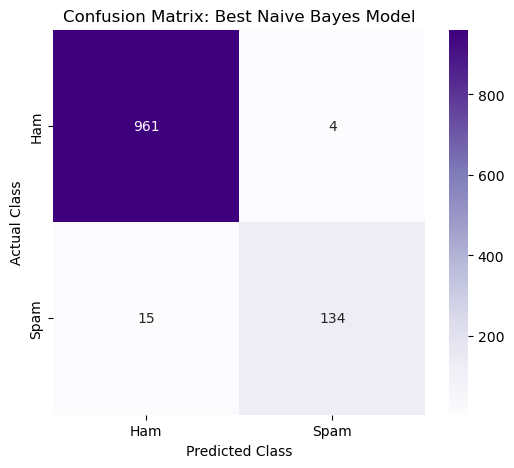

In [16]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title(f"Confusion Matrix: Best Naive Bayes Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()